Importing the Dependencies

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection and Processing

In [55]:
# Loading the data from csv file to Pandas DataFrame
car_dataset = pd.read_csv(r'C:\Users\Vikram\OneDrive\Desktop\ML Projects\Projects\7.1. Car Price Prediction dataset.csv')

In [56]:
# Inspecting the first 5 rows of the dataset
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [57]:
# Checking the number of rows and columns
car_dataset.shape

(4340, 8)

In [58]:
# Getting some information about the dataset
car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [59]:
# Checking the number of missing values
car_dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [60]:
# Checking the distribution of Categorical data
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())
print(car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


Label Encoding: Encoding the Categorical Data

In [61]:
# Encoding 'fuel' column
car_dataset.replace({'fuel':{'Petrol':0, 'Diesel':1, 'CNG':2, 'LPG':3, 'Electric':4}}, inplace=True)

# Encoding 'seller_type' column
car_dataset.replace({'seller_type':{'Dealer':0, 'Individual':1, 'Trustmark Dealer':2}}, inplace=True)

# Encoding 'transmission' column
car_dataset.replace({'transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

# Encoding 'owner' column
car_dataset.replace({'owner':{'First Owner':0, 'Second Owner':1, 'Third Owner':2, 'Fourth & Above Owner':3, 'Test Drive Car':4}}, inplace=True)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,1
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,1,1,0,1
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,1,1,0,1
4337,Maruti 800 AC BSIII,2009,110000,83000,0,1,0,1
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,1,1,0,0


Splitting the data and Target

In [62]:
X = car_dataset.drop(columns=['name', 'selling_price'])
Y = car_dataset['selling_price']

In [63]:
print(X)

      year  km_driven fuel seller_type transmission owner
0     2007      70000    0           1            0     0
1     2007      50000    0           1            0     0
2     2012     100000    1           1            0     0
3     2017      46000    0           1            0     0
4     2014     141000    1           1            0     1
...    ...        ...  ...         ...          ...   ...
4335  2014      80000    1           1            0     1
4336  2014      80000    1           1            0     1
4337  2009      83000    0           1            0     1
4338  2016      90000    1           1            0     0
4339  2016      40000    0           1            0     0

[4340 rows x 6 columns]


In [64]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


Splitting the data into Training and Test data

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

Model Training

1. Linear Regression

In [66]:
# Loading the Linear Regression model
lin_reg_model = LinearRegression()

In [67]:
lin_reg_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Evaluation

In [68]:
# Pediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [69]:
# R-squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print(f"R-squared Error: {error_score}")

R-squared Error: 0.4276361285018685


Visualize the Actual Prices and Predicted Prices

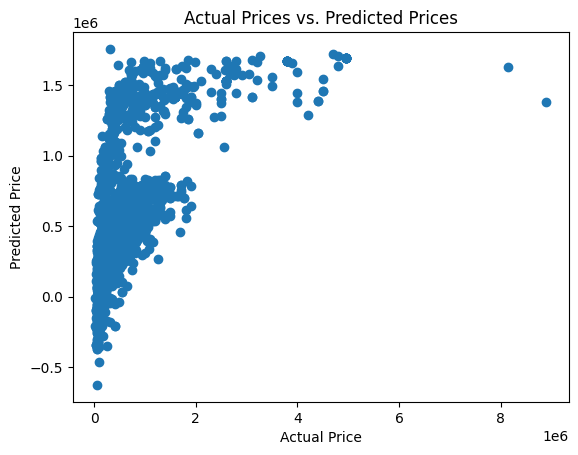

In [70]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

In [71]:
# Prediction on Test data
test_data_prediction = lin_reg_model.predict(X_test)

In [72]:
# R-squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print(f"R-squared Error: {error_score}")

R-squared Error: 0.5027999353753423


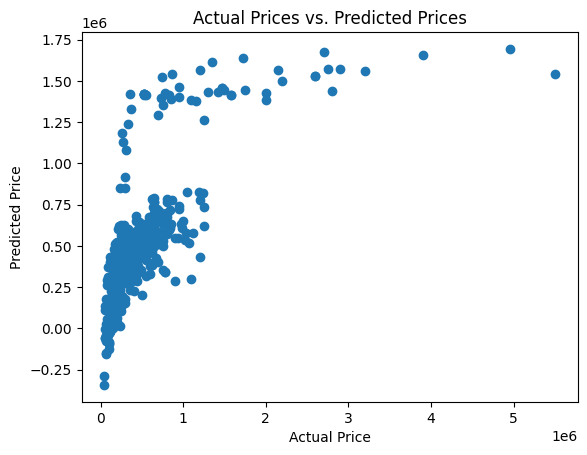

In [73]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

2. Lasso Regression

In [74]:
# Loading the Lasso model
lass_reg_model = Lasso()

In [75]:
lass_reg_model.fit(X_train, Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Model Evaluation

In [76]:
# Predicting on Training data
training_data_prediction = lass_reg_model.predict(X_train)

In [77]:
# R-squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print(f"R-squared Error: {error_score}")

R-squared Error: 0.42763612844686594


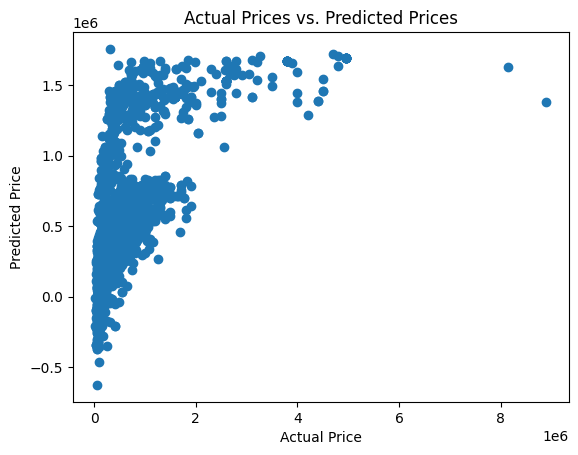

In [78]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

In [79]:
# Prediction on Test data
test_data_prediction = lass_reg_model.predict(X_test)

In [80]:
# R-squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print(f"R-squared Error: {error_score}")

R-squared Error: 0.5027994839428167


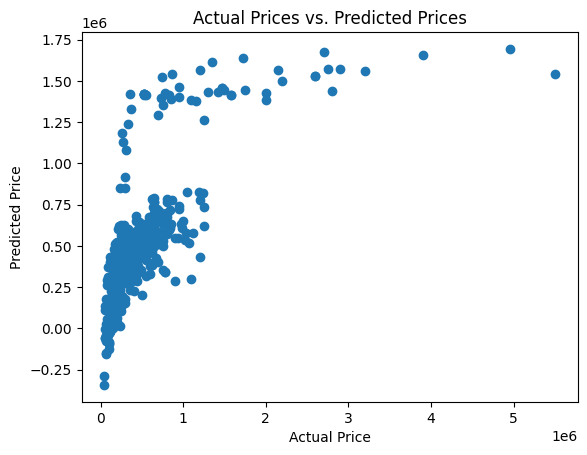

In [81]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()